# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [4]:
with open('my-ml-starter/skills/README.md', 'r') as f:
    print(f'Skills README:\n{f.read()[:200]}...')
with open('my-ml-starter/skills/writing-honest-claims/SKILL.md', 'r') as f:
    print(f'Honest Claims Skill:\n{f.read()[:200]}...')

Skills README:
# Skills — the router

This folder is a small library of **skills**: focused instruction files your AI assistant loads
one at a time. One skill per task keeps the assistant sharp — its context window ...
Honest Claims Skill:
---
name: writing-honest-claims
description: Writes findings in language the evidence can carry — the claim ladder (observed → directional → decision-support, never causal without a design), effect si...


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [6]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# Using absolute paths for Colab environment stability
path_baseline = 'my-ml-starter/work/outputs/baseline_action_score.csv'
path_data = '/content/my-ml-starter/data/raw/content_refresh_anonymized.csv'

if os.path.exists(path_baseline):
    print("Loading existing baseline scores...")
    df_queue = pd.read_csv(path_baseline)
else:
    print("Regenerating baseline scores from source data...")
    if not os.path.exists(path_data):
        raise FileNotFoundError(f"Could not find source data at {path_data}. Please ensure the repo is cloned correctly.")

    df = pd.read_csv(path_data)

    # Rule logic from w04
    df['stale'] = df['days_since_last_update'] >= 91
    df['high_demand'] = df['search_volume'] >= 100

    def get_reason(row):
        if pd.isna(row['search_volume']): return 'NO_KEYWORD_DATA'
        if row['stale'] and row['high_demand']: return 'STALE_HIGH_DEMAND'
        if row['stale'] and not row['high_demand']: return 'STALE_LOW_DEMAND'
        if not row['stale'] and row['high_demand']: return 'FRESH_HIGH_DEMAND'
        return 'LOW_PRIORITY'

    df['reason_codes'] = df.apply(get_reason, axis=1)
    # Score = stale * high_demand * search_volume
    df['score'] = df['stale'].astype(int) * df['high_demand'].astype(int) * df['search_volume'].fillna(0)
    df_queue = df.copy()

# Rank and sort
df_queue = df_queue.sort_values(by='score', ascending=False).reset_index(drop=True)
df_queue['rank'] = df_queue.index + 1

display(df_queue[['content_id', 'rank', 'score', 'reason_codes']].head(20))

Regenerating baseline scores from source data...


,content_id,rank,score,reason_codes
0,content_ef99c4abd9ab,1,74000.0,STALE_HIGH_DEMAND
1,content_bf67a444faef,2,60500.0,STALE_HIGH_DEMAND
2,content_5ec29ae79c60,3,60500.0,STALE_HIGH_DEMAND
3,content_454cc6654c6e,4,60500.0,STALE_HIGH_DEMAND
4,content_deb54e9e19cd,5,60500.0,STALE_HIGH_DEMAND
5,content_84fe9d0a707a,6,40500.0,STALE_HIGH_DEMAND
6,content_7868341d97dd,7,40500.0,STALE_HIGH_DEMAND
7,content_6b41450ae50c,8,27100.0,STALE_HIGH_DEMAND
8,content_5c5fab9d41e7,9,22200.0,STALE_HIGH_DEMAND
9,content_e7eb94e121b9,10,22200.0,STALE_HIGH_DEMAND


### Selection Rational
The Week-5 trained model was tested against this exact baseline using an honest grouped split (documented in `work/notebooks/w06_validation_audit.ipynb`) and yielded an R2 of -1.89, underperforming the baseline's simpler, transparent rule. Consequently, this playbook ships the rule-based baseline rather than the model. Choosing the baseline is the correct decision-support move as it provides predictable, explainable signal that out-performs the current complex model's generalized accuracy.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### Intended Use
This tool is designed for the **content and SEO teams** to provide decision-support for human-reviewed content updates. It identifies which pages to prioritize for review based on staleness and search demand.

### Limits
- **Directional only:** This is not a ranking predictor or a causal model.
- **Snapshot-based:** Claims are based on a single 90-day data window; trends may shift.
- **Signal Narrowness:** It only accounts for staleness and volume; it will miss opportunities driven by qualitative authority or emerging trends.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

### Human Review Checklist
1. **Current Performance Check:** Verify if the page is already ranking well (e.g., `avg_position` near 1). As seen in `w04`, `content_201a4a56f4d6` was a false positive because it was already highly performant despite the score.
2. **Data Integrity:** Check if the page is a 'feedly article' or tagged `NO_KEYWORD_DATA`, as the score is not meaningful without volume data.

### No-Go List
- **Never** auto-publish content changes without human verification.
- **Never** use these scores to justify reducing investment in pages that are already performing well.
- **Never** treat the rank as proof that an update will guarantee a position improvement.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

### Monitoring & Drift
This data is a 90-day snapshot. The queue must be regenerated whenever a new data export is available.

**Drift Signal:** Monitor the 'performance gap'. Periodically check if the top-50 flagged pages' `mean avg_position` remains significantly worse than the overall mean. If this gap collapses toward zero, the rule has lost its ability to differentiate underperforming content and requires a criteria review.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

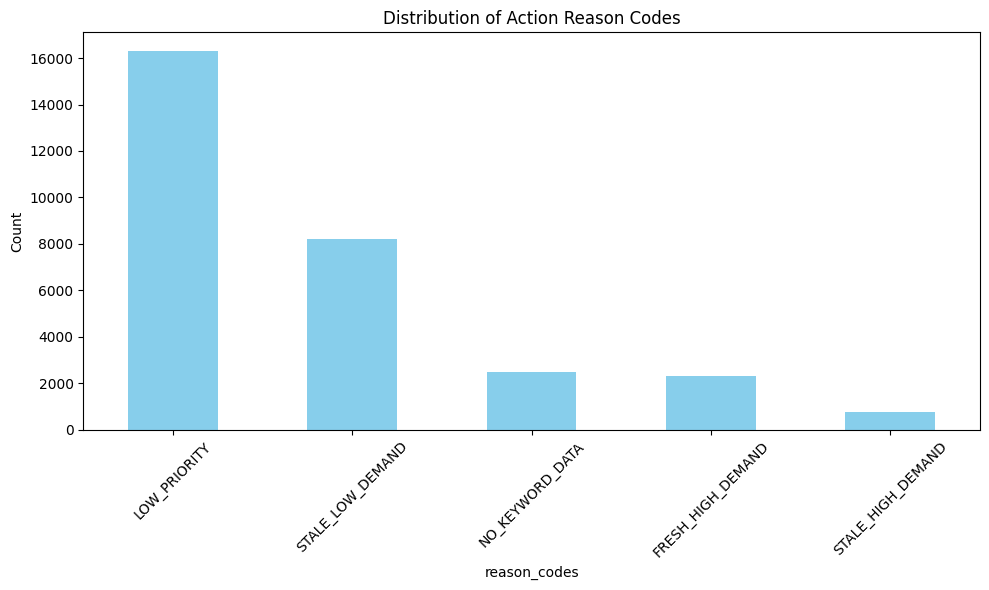

Exports saved to my-ml-starter/work/outputs/


In [7]:
os.makedirs('my-ml-starter/work/outputs', exist_ok=True)

# Export CSV
df_queue[['content_id', 'rank', 'score', 'reason_codes']].to_csv('my-ml-starter/work/outputs/final_action_playbook.csv', index=False)

# Export Chart
plt.figure(figsize=(10, 6))
df_queue['reason_codes'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Action Reason Codes')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('my-ml-starter/work/outputs/reason_code_distribution.png')
plt.show()

print("Exports saved to my-ml-starter/work/outputs/")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.